In [2]:
data_2009_2010=pd.read_excel(r"E:\SEM 8\Sales_Intelligence_System\Datasets\Online Retail Dataset\online_retail_II.xlsx", sheet_name="Year 2009-2010")
data_2010_2011=pd.read_excel(r"E:\SEM 8\Sales_Intelligence_System\Datasets\Online Retail Dataset\online_retail_II.xlsx", sheet_name="Year 2010-2011")

In [3]:
data_2009_2010.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [4]:
data_2010_2011.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [5]:
data_2009_2010.shape,data_2010_2011.shape

((525461, 8), (541910, 8))

In [6]:
data=pd.concat([data_2009_2010,data_2010_2011],ignore_index=True)

In [7]:
data.shape

(1067371, 8)

In [8]:
data.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371.0,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628.0,5305,5698,NaN,NaN,NaN,NaN,43
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1350.0,5829,5918,NaN,NaN,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504,NaN
min,NaN,NaN,NaN,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,NaN
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,NaN


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [10]:
data.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [11]:
data=data.rename(columns={'Description':'Product'})

In [12]:
data=data.dropna(subset=['Customer ID'])

In [13]:
data.shape

(824364, 8)

In [14]:
data=data[~data['Invoice'].astype(str).str.startswith('C')]

In [15]:
data.shape

(805620, 8)

In [16]:
data=data[(data['Quantity']>0) & (data['Price']>0)]

In [17]:
data.shape

(805549, 8)

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Product      805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[ns]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 55.3+ MB


In [19]:
data['TotalPrice'] = data['Quantity'] * data['Price']

In [20]:
data.head(3)

,Invoice,StockCode,Product,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0


In [21]:
data.describe(include='all')

,Invoice,StockCode,Product,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
count,805549.0,805549,805549,805549.000000,805549,805549.000000,805549.000000,805549,805549.000000
unique,36969.0,4631,5283,NaN,NaN,NaN,NaN,41,NaN
top,576339.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom,NaN
freq,542.0,5188,5181,NaN,NaN,NaN,NaN,725250,NaN
mean,NaN,NaN,NaN,13.290522,2011-01-02 10:24:44.106814464,3.206561,15331.954970,NaN,22.026505
min,NaN,NaN,NaN,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,NaN,0.001000
25%,NaN,NaN,NaN,2.000000,2010-07-07 12:08:00,1.250000,13982.000000,NaN,4.950000
50%,NaN,NaN,NaN,5.000000,2010-12-03 15:10:00,1.950000,15271.000000,NaN,11.850000
75%,NaN,NaN,NaN,12.000000,2011-07-28 13:05:00,3.750000,16805.000000,NaN,19.500000
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,NaN,168469.600000


# RFM

In [22]:
reference_date = data['InvoiceDate'].max()

In [23]:
rfm = data.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.reset_index(inplace=True)

In [24]:
rfm.head(3)

,Customer ID,Recency,Frequency,Monetary
0,12346.0,325,12,77556.46
1,12347.0,1,8,5633.32
2,12348.0,74,5,2019.40


array([[<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>, <Axes: >]], dtype=object)

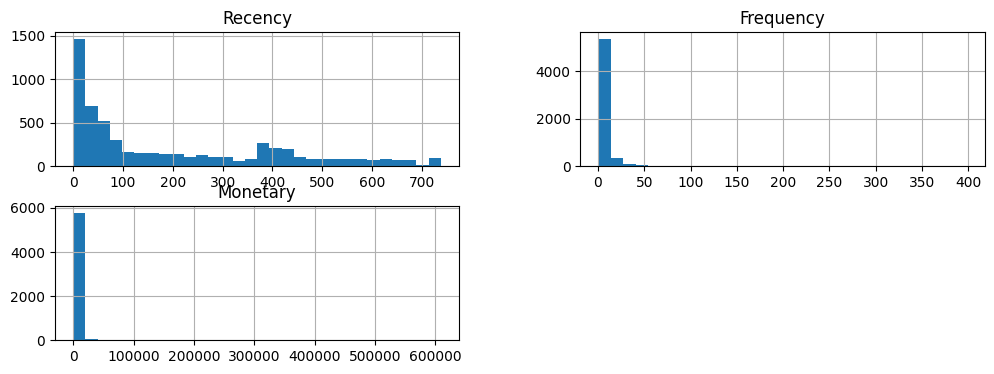

In [25]:
rfm[['Recency','Frequency','Monetary']].hist(figsize=(12,4),bins=30)

In [26]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [27]:
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

In [28]:
rfm['RFM_Score']=( rfm['R_Score']*100 + rfm['F_Score']*10 + rfm['M_Score'])

In [29]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,325,12,77556.46,2,5,5,255
1,12347.0,1,8,5633.32,5,4,5,545
2,12348.0,74,5,2019.40,3,4,4,344
3,12349.0,18,4,4428.69,5,3,5,535
4,12350.0,309,1,334.40,2,1,2,212


In [30]:
def segment_customer(row):
    if row['RFM_Score']>=444:
        return 'Champion'
    elif row['F_Score']>=4:
        return 'Loyal Customer'
    elif row['R_Score']<=2 and row['F_Score']>=3:
        return 'At Risk'
    elif row['R_Score']==1:
        return 'Lost Customer'
    else:
        return 'Potential Customer'

In [31]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm['Segment'].value_counts()

Segment
Potential Customer    1803
Champion              1747
Loyal Customer         955
Lost Customer          902
At Risk                471
Name: count, dtype: int64

In [32]:
rfm.shape

(5878, 9)

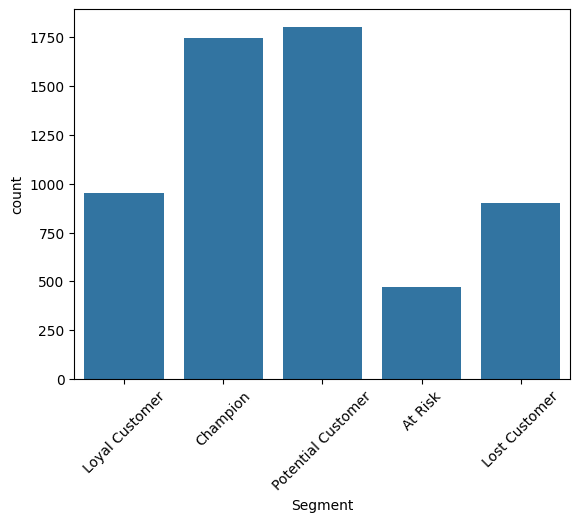

In [33]:
sns.countplot(x='Segment', data=rfm)
plt.xticks(rotation=45)
plt.show()

# Creating dataset for lead scoring using existing dataset

In [34]:
lead_data=rfm.copy()

In [35]:
lead_data['AvgOrderValue'] = lead_data['Monetary'] / lead_data['Frequency']

In [36]:
lead_data['PurchaseIntensity'] = lead_data['Frequency'] / (lead_data['Recency'] + 1)

In [37]:
product_div = data.groupby('Customer ID')['StockCode'].nunique().reset_index()
product_div.columns = ['Customer ID', 'ProductDiversity']

lead_data = lead_data.merge(product_div, on='Customer ID')

In [38]:
customer_active_days = data.groupby('Customer ID')['InvoiceDate'].agg(['min', 'max'])
customer_active_days['Customer_active_days'] = (customer_active_days['max'] - customer_active_days['min']).dt.days

lead_data = lead_data.merge(customer_active_days['Customer_active_days'], on='Customer ID')

In [39]:
lead_data.head(3)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,AvgOrderValue,PurchaseIntensity,ProductDiversity,Customer_active_days
0,12346.0,325,12,77556.46,2,5,5,255,Loyal Customer,6463.038333,0.036810,27,400
1,12347.0,1,8,5633.32,5,4,5,545,Champion,704.165000,4.000000,126,402
2,12348.0,74,5,2019.40,3,4,4,344,Loyal Customer,403.880000,0.066667,25,362


In [40]:
lead_data['email_click_rate'] = (
    lead_data['F_Score'] + lead_data['M_Score']
) / 10

In [41]:
lead_data['website_visits'] = (
    lead_data['Frequency'] * 2 + np.random.randint(1, 10, len(lead_data))
)

In [42]:
lead_data['time_on_site'] = (
    lead_data['website_visits'] * np.random.randint(5, 15, len(lead_data))
)

In [43]:
lead_data['discount_response'] = np.where(
    lead_data['R_Score'].astype(int) >= 4, 1, 0
)

In [44]:
lead_data['LeadScore'] = (
    lead_data['R_Score'].astype(int) * 15 +
    lead_data['F_Score'].astype(int) * 15 +
    lead_data['M_Score'].astype(int) * 15 +
    (lead_data['PurchaseIntensity'] * 10) +
    (lead_data['ProductDiversity'] * 2) +
    (lead_data['email_click_rate'] * 20)
)

In [45]:
lead_data.head(3)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,AvgOrderValue,PurchaseIntensity,ProductDiversity,Customer_active_days,email_click_rate,website_visits,time_on_site,discount_response,LeadScore
0,12346.0,325,12,77556.46,2,5,5,255,Loyal Customer,6463.038333,0.036810,27,400,1.0,28,168,0,254.368098
1,12347.0,1,8,5633.32,5,4,5,545,Champion,704.165000,4.000000,126,402,0.9,24,264,1,520.000000
2,12348.0,74,5,2019.40,3,4,4,344,Loyal Customer,403.880000,0.066667,25,362,0.8,11,77,0,231.666667


In [46]:
print(lead_data['LeadScore'].min())
print(lead_data['LeadScore'].max())

51.013531799729364
9325.0


In [47]:
min_score = lead_data['LeadScore'].min()
max_score = lead_data['LeadScore'].max()

lead_data['LeadScore_Normalized'] = (
    (lead_data['LeadScore'] - min_score) / (max_score - min_score)
) * 100

In [48]:
print(lead_data['LeadScore_Normalized'].min())
print(lead_data['LeadScore_Normalized'].max())

0.0
100.0


In [49]:
lead_data[['Customer ID', 'LeadScore', 'LeadScore_Normalized']].head()

,Customer ID,LeadScore,LeadScore_Normalized
0,12346.0,254.368098,2.192742
1,12347.0,520.000000,5.057010
2,12348.0,231.666667,1.947956
3,12349.0,489.105263,4.723877
4,12350.0,115.032258,0.690304


In [50]:
lead_data['LeadScore_Log'] = np.log1p(lead_data['LeadScore'])

In [51]:
min_score = lead_data['LeadScore_Log'].min()
max_score = lead_data['LeadScore_Log'].max()

lead_data['LeadScore_Final'] = (
    (lead_data['LeadScore_Log'] - min_score) /
    (max_score - min_score)
) * 100

In [52]:
lead_data[['Customer ID', 'LeadScore', 'LeadScore_Final']].head()

,Customer ID,LeadScore,LeadScore_Final
0,12346.0,254.368098,30.664569
1,12347.0,520.000000,44.405869
2,12348.0,231.666667,28.870424
3,12349.0,489.105263,43.227816
4,12350.0,115.032258,15.462621


In [53]:
lead_data.describe()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,AvgOrderValue,PurchaseIntensity,ProductDiversity,Customer_active_days,email_click_rate,website_visits,time_on_site,discount_response,LeadScore,LeadScore_Normalized,LeadScore_Log,LeadScore_Final
count,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.00000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,200.331916,6.289384,3018.616737,3.005104,3.000000,3.000000,333.510378,391.726538,1.057754,81.989112,273.022457,0.60000,17.564137,166.692923,0.402178,321.632317,2.918042,5.494146,29.728745
std,1715.572666,209.338707,13.009406,14737.731040,1.416969,1.414454,1.414454,150.378937,1215.071054,9.169120,116.484552,258.807591,0.26891,26.168676,260.222677,0.490379,325.206846,3.506656,0.729496,14.058357
min,12346.000000,0.000000,1.000000,2.950000,1.000000,1.000000,1.000000,111.000000,2.950000,0.001353,1.000000,0.000000,0.20000,3.000000,15.000000,0.000000,51.013532,0.000000,3.951504,0.000000
25%,13833.250000,25.000000,1.000000,348.762500,2.000000,2.000000,2.000000,214.000000,181.652500,0.005239,19.000000,0.000000,0.40000,8.000000,66.000000,0.000000,140.110275,0.960717,4.949542,19.233507
50%,15314.500000,95.000000,3.000000,898.915000,3.000000,3.000000,3.000000,334.000000,285.070500,0.031209,45.000000,220.500000,0.60000,11.000000,110.000000,0.000000,238.833333,2.025233,5.479944,29.455061
75%,16797.750000,379.000000,7.000000,2307.090000,4.000000,4.000000,4.000000,454.000000,420.570000,0.208333,103.000000,511.000000,0.80000,19.000000,182.000000,1.000000,402.564419,3.790720,6.000336,39.483706
max,18287.000000,738.000000,398.000000,608821.650000,5.000000,5.000000,5.000000,555.000000,84236.250000,398.000000,2550.000000,738.000000,1.00000,799.000000,7990.000000,1.000000,9325.000000,100.000000,9.140561,100.000000


<Axes: >

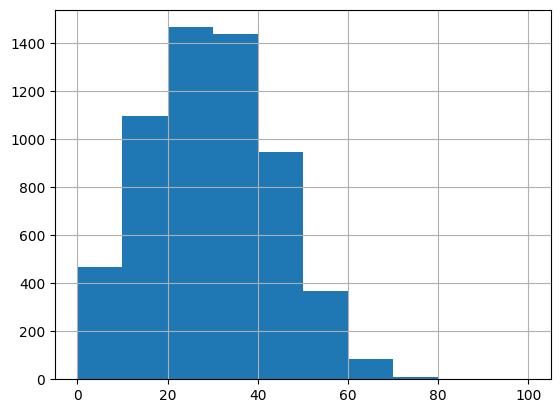

In [54]:
lead_data['LeadScore_Final'].hist()

In [55]:
lead_data.head(3)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,AvgOrderValue,...,ProductDiversity,Customer_active_days,email_click_rate,website_visits,time_on_site,discount_response,LeadScore,LeadScore_Normalized,LeadScore_Log,LeadScore_Final
0,12346.0,325,12,77556.46,2,5,5,255,Loyal Customer,6463.038333,...,27,400,1.0,28,168,0,254.368098,2.192742,5.542706,30.664569
1,12347.0,1,8,5633.32,5,4,5,545,Champion,704.165000,...,126,402,0.9,24,264,1,520.000000,5.057010,6.255750,44.405869
2,12348.0,74,5,2019.40,3,4,4,344,Loyal Customer,403.880000,...,25,362,0.8,11,77,0,231.666667,1.947956,5.449607,28.870424


In [56]:
lead_data=lead_data.drop(['LeadScore_Normalized'],axis=1)

In [57]:
lead_data.head(10)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,AvgOrderValue,PurchaseIntensity,ProductDiversity,Customer_active_days,email_click_rate,website_visits,time_on_site,discount_response,LeadScore,LeadScore_Log,LeadScore_Final
0,12346.0,325,12,77556.46,2,5,5,255,Loyal Customer,6463.038333,0.036810,27,400,1.0,28,168,0,254.368098,5.542706,30.664569
1,12347.0,1,8,5633.32,5,4,5,545,Champion,704.165000,4.000000,126,402,0.9,24,264,1,520.000000,6.255750,44.405869
2,12348.0,74,5,2019.40,3,4,4,344,Loyal Customer,403.880000,0.066667,25,362,0.8,11,77,0,231.666667,5.449607,28.870424
3,12349.0,18,4,4428.69,5,3,5,535,Champion,1107.172500,0.210526,138,570,0.8,10,120,1,489.105263,6.194620,43.227816
4,12350.0,309,1,334.40,2,1,2,212,Potential Customer,334.400000,0.003226,17,0,0.3,7,91,0,115.032258,4.753868,15.462621
5,12351.0,374,1,300.93,2,1,2,212,Potential Customer,300.930000,0.002667,21,0,0.3,8,112,0,123.026667,4.820497,16.746638
6,12352.0,35,10,2849.84,4,5,4,454,Champion,284.984000,0.277778,70,356,0.9,28,224,1,355.777778,5.877113,37.109035
7,12353.0,203,2,406.76,2,2,2,222,Potential Customer,203.380000,0.009804,23,204,0.4,13,91,0,144.098039,4.977410,19.770560
8,12354.0,231,1,1079.40,2,1,3,213,Potential Customer,1079.400000,0.004310,58,0,0.4,10,80,0,214.043103,5.370838,27.352454
9,12355.0,213,2,947.61,2,2,3,223,Potential Customer,473.805000,0.009346,35,353,0.5,10,50,0,185.093458,5.226249,24.566023


In [58]:
lead_data.to_csv('lead_scoring_final.csv', index=False)

In [60]:
    q1 = lead_data['LeadScore_Final'].quantile(0.33)
    q2 = lead_data['LeadScore_Final'].quantile(0.66)

In [61]:
q1,q2

(22.72906592436913, 35.4981080436894)